# Lab 3

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [12]:
# Load in the dataset
iris = datasets.load_iris()
X = iris.data
Y = iris.target

# Convert to dataframe and print head
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [13]:
# Summary statistics
print(iris_df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


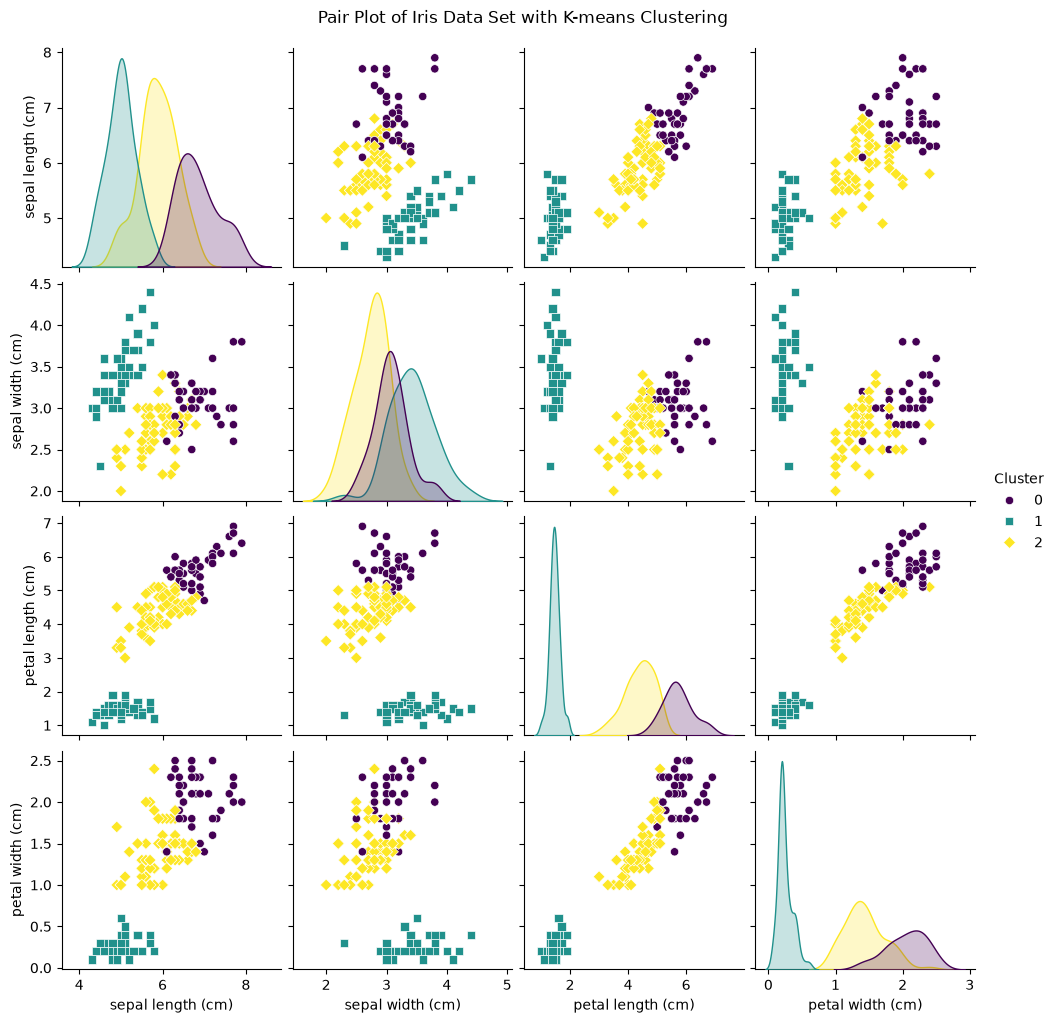

In [14]:
# K-means clustering, fitting
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

# Plotting the clusters
iris_df['Cluster'] = labels
sns.pairplot(iris_df, hue='Cluster', palette='viridis', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Data Set with K-means Clustering', y=1.02)
plt.show()

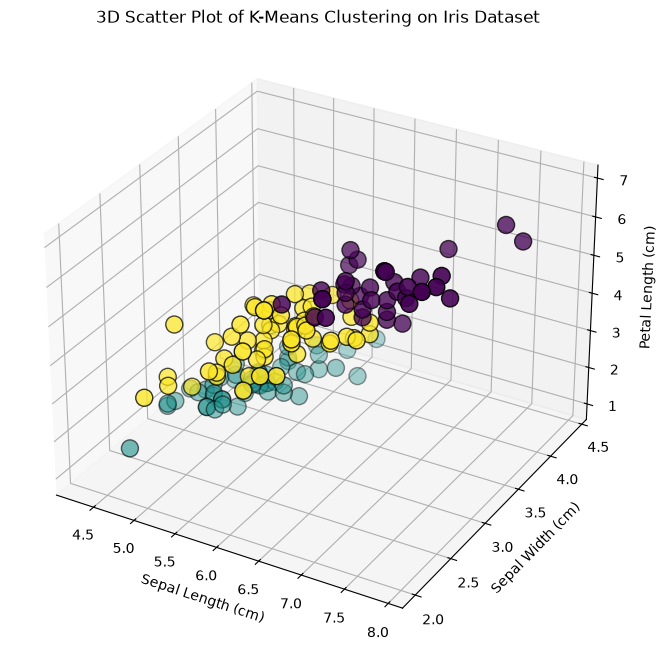

In [15]:
# 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], iris_df['petal length (cm)'],
           c=iris_df['Cluster'], cmap='viridis', edgecolors='k', s=150)

ax.set_title('3D Scatter Plot of K-Means Clustering on Iris Dataset')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_zlabel('Petal Length (cm)')

plt.show()

In [16]:
# Find cluster centres
print(f'Cluster Centers:\n{kmeans.cluster_centers_}')

Cluster Centers:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [17]:
# Calculate interia
print(f'Inertia: {kmeans.inertia_}')

Inertia: 78.8556658259773


In [18]:
# Calculate silhouette score
silhouette_avg = silhouette_score(X, labels)
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.5511916046195919


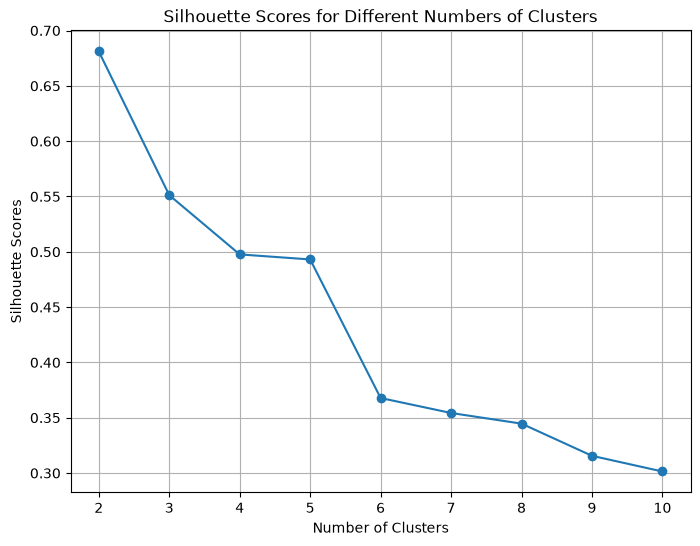

In [19]:
# Calculate optimal value for k using silhouette scores
silhouette_scores = []
k_range = range(2, 11)

for k_clusters in k_range:
    kmeans = KMeans(n_clusters=k_clusters, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Scores')
plt.xticks(k_range)
plt.grid(True)
plt.show()